# 2-Mirror Multipass Configuration
## V-Shape zig-zag setup with fixed M1 and optimizable M2
- M1 at origin, M2 at 60 cm (both 2-inch = 5.08 cm diameter)
- Fixed laser input: constant angle, fixed point on M2
- Detector plane above mirrors (with small tilt)
- Optimize for 10-20 passes with clipping penalty and beam divergence

In [1]:
import sys
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import traceback

# Import local modules
sys.path.insert(0, '.')
from Math.vector import Vector
from Math.matrix import Matrix
from Math.grid import TwoGrid
from Geometry.mirror import Mirror
from Geometry.cell_geometry import CellGeometry
from Physics.lightray import Lightray
from Physics.Physics import PhysicsUtils
from Core.gas_cell import GasCell
from Results.track_memory import TrackMemory
from Results.raystate import Raystate
from Results.Config import Config

In [2]:
class TwoMirrorSearchSpace:
    """
    Search space for 2-mirror multipass configuration.
    M1 is fixed, M2 angles are optimizable.
    """
    def __init__(self):
        # M2 angle ranges (degrees)
        self.theta_x2_base = 0.0  # Roll angle
        self.theta_y2_base = 0.0  # Pitch angle
        
        # Vertical tilt for spot distribution (raster pattern)
        self.vertical_tilt_base = 0.0
        
        # Search ranges (gets smaller during optimization)
        self.angle_range_m2 = 2.0  # degrees
        self.tilt_range = 0.5  # degrees
        
    def get_random_config(self):
        return {
            "theta_x2": self.theta_x2_base + random.uniform(-self.angle_range_m2, self.angle_range_m2),
            "theta_y2": self.theta_y2_base + random.uniform(-self.angle_range_m2, self.angle_range_m2),
            "vertical_tilt": self.vertical_tilt_base + random.uniform(-self.tilt_range, self.tilt_range),
        }
    
    def perturb(self, current_config):
        new_cfg = current_config.copy()
        
        # Perturb M2 angles
        for key in ["theta_x2", "theta_y2"]:
            step = random.uniform(-self.angle_range_m2, self.angle_range_m2)
            if random.random() < 0.05:
                step *= 10  # Occasional large jump
            new_cfg[key] = np.clip(new_cfg[key] + step, -6.0, 6.0)
        
        # Perturb vertical tilt
        step = random.uniform(-self.tilt_range, self.tilt_range)
        if random.random() < 0.05:
            step *= 10
        new_cfg["vertical_tilt"] = np.clip(new_cfg["vertical_tilt"] + step, -2.0, 2.0)
        
        return new_cfg
    
    def microscope(self, search_mode):
        """Reduce search ranges as optimization progresses."""
        if search_mode == "coarse":
            self.angle_range_m2 = 2.0
            self.tilt_range = 0.5
        elif search_mode == "fine":
            self.angle_range_m2 = 0.5
            self.tilt_range = 0.1
        elif search_mode == "ultra_fine":
            self.angle_range_m2 = 0.1
            self.tilt_range = 0.02

In [3]:
class TwoMirrorFitnessEvaluator:
    """
    Evaluate fitness for 2-mirror multipass configuration.
    Targets: specific number of passes, spot position on detector, no clipping.
    """
    def __init__(self, target_passes=15, detector_size=0.05, clipping_threshold=0.05):
        self.target_passes = target_passes
        self.detector_size = detector_size  # meters (5 cm × 5 cm)
        self.clipping_threshold = clipping_threshold  # 5% threshold
        
        # Beam parameters
        self.wavelength_um = 1654e-6  # micrometers -> meters
        self.initial_beam_diameter_mm = 3.6  # mm at waist
        
        # Mirror geometry
        self.mirror_diameter = 0.0508  # 2 inch = 5.08 cm
        self.mirror_radius = self.mirror_diameter / 2.0
        
    def calculate_beam_diameter_at_distance(self, distance_m):
        """
        Gaussian beam divergence: w(z) = w0 * sqrt(1 + (λz / πw0²)²)
        """
        w0 = self.initial_beam_diameter_mm / 2.0 / 1000.0  # Convert to meters, get waist
        z = distance_m
        w = w0 * math.sqrt(1.0 + ((self.wavelength_um * z) / (math.pi * w0**2))**2)
        return 2.0 * w * 1000.0  # Return in mm
    
    def calculate_clipping_penalty(self, track_memory):
        """
        Estimate power loss due to clipping on mirror edges.
        Assumes circular mirrors.
        """
        if not track_memory.memory:
            return 0.0
        
        total_clipping_loss = 0.0
        cumulative_distance = 0.0
        
        for idx, state in enumerate(track_memory.memory):
            if getattr(state, 'event_type', 'reflection') != 'reflection':
                continue
            
            # Estimate beam diameter at this reflection
            beam_dia_mm = self.calculate_beam_diameter_at_distance(cumulative_distance / 1000.0)
            beam_radius_mm = beam_dia_mm / 2.0
            
            # Distance from mirror center (rough estimate from u, v)
            spot_distance_mm = math.sqrt(state.u**2 + state.v**2)
            
            # Check if beam extends beyond mirror edge
            edge_distance_mm = (self.mirror_radius * 1000.0) - spot_distance_mm
            
            if edge_distance_mm < beam_radius_mm:
                # Clipping occurs
                clipping_fraction = (beam_radius_mm - edge_distance_mm) / beam_radius_mm
                total_clipping_loss += min(1.0, clipping_fraction)
            
            # Update distance for next iteration
            if idx < len(track_memory.memory) - 1:
                next_state = track_memory.memory[idx + 1]
                segment_length = (state.position - next_state.position).norm()
                cumulative_distance += segment_length
        
        return total_clipping_loss
    
    def calculate_score(self, track_memory, final_spot_error, clipping_loss):
        """
        Multi-objective fitness score:
        - Bonus for correct number of passes
        - Penalty for spot position error on detector
        - Penalty for beam clipping
        """
        num_reflections = len(track_memory.memory)
        
        score = 0.0
        
        # 1. Reflection count penalty
        bounce_diff = abs(self.target_passes - num_reflections)
        if bounce_diff == 0:
            score += 1e7  # Bonus for exact target
        else:
            score -= (bounce_diff**2) * 1e5
        
        # 2. Spot position penalty (want it centered on detector)
        score -= final_spot_error * 1e6
        
        # 3. Clipping penalty (significant)
        if clipping_loss > self.clipping_threshold:
            excess_clipping = clipping_loss - self.clipping_threshold
            score -= excess_clipping * 1e9
        
        return score

In [4]:
class TwoMirrorFindingGeometry:
    """
    Setup and optimization of 2-mirror multipass configuration.
    Plane-parallel cell: M1 and M2 face each other, laser bounces between them.
    """
    def __init__(self, target_passes=15, iterations=100000, 
                 mirror_sep_cm=60.0, mirror_diameter_cm=5.08):
        self.search_space = TwoMirrorSearchSpace()
        self.target_passes = target_passes
        self.iterations = iterations
        
        # Fixed geometry parameters
        self.mirror_sep_m = mirror_sep_cm / 100.0
        self.mirror_diameter_m = mirror_diameter_cm / 100.0
        self.mirror_radius_m = self.mirror_diameter_m / 2.0
        
        # M1 at origin, fixed orientation
        self.pos_m1 = Vector(0, 0, 0)
        self.normal_m1 = Vector(0, 1, 0).normalize()  # Pointing toward M2
        
        # M2 at fixed distance along Y
        self.pos_m2_base = Vector(0, self.mirror_sep_m, 0)
        
        # Laser input
        self.laser_entry_height_m = 0.022  # 2.2 cm above mirror center
        self.laser_incident_angle_deg = 45.0  # Fixed incident angle
        
        self.evaluator = TwoMirrorFitnessEvaluator(target_passes=target_passes)
        
        # Tracking
        self.best_score = -float("inf")
        self.best_config = None
        self.best_track_memory = None
        self.current_score = -float("inf")
        self.current_config = None
        
        self.temperature = 1000.0
        self.cooling_rate = 0.9999
        self.no_improve_counter = 0
    
    def _setup_cell(self, config):
        """
        Build plane-parallel cell: M1 and M2 face each other horizontally.
        """
        try:
            # M1: pointing in +Y direction (toward M2)
            m1 = Mirror(
                name="M1",
                origin=self.pos_m1,
                normal=Vector(0, 1, 0).normalize(),
                grid=TwoGrid(self.mirror_diameter_m * 100, self.mirror_diameter_m * 100, 0.1),
                reflection_coef=0.95
            )
            
            # M2: tilted by theta_x2, theta_y2
            theta_x2 = math.radians(config["theta_x2"])
            theta_y2 = math.radians(config["theta_y2"])
            
            normal_m2_base = Vector(0, -1, 0)
            rot_x = Matrix.rotation_x(theta_x2)
            rot_y = Matrix.rotation_y(theta_y2)
            normal_m2 = (rot_y @ rot_x @ normal_m2_base).normalize()
            
            m2 = Mirror(
                name="M2",
                origin=self.pos_m2_base,
                normal=normal_m2,
                grid=TwoGrid(self.mirror_diameter_m * 100, self.mirror_diameter_m * 100, 0.1),
                reflection_coef=0.95
            )
            
            # Create cell geometry
            cell_geo = CellGeometry("TwoMirrorCell", cell_dimensions=(1, 1, 1))
            cell_geo.add_mirror(m1)
            cell_geo.add_mirror(m2)
            
            # Laser: horizontal, enters from left, bounces M1 <-> M2
            laser_x_start = -0.1
            laser_y_mid = self.mirror_sep_m / 2.0
            entry_point = Vector(laser_x_start, laser_y_mid, self.laser_entry_height_m)
            
            incident_angle_rad = math.radians(self.laser_incident_angle_deg)
            laser_dir = Vector(
                math.cos(incident_angle_rad),
                math.sin(incident_angle_rad),
                0.0
            ).normalize()
            
            return GasCell(cell_geo), entry_point, laser_dir, m1, m2
        
        except Exception as e:
            print(f"Error in _setup_cell: {e}")
            traceback.print_exc()
            return None, None, None, None, None
    
    def _trace_ray_until_exit(self, cell, entry_point, laser_dir, max_reflections=50):
        """Trace ray until exit."""
        ray = Lightray(entry_point, laser_dir)
        track_mem = cell.run_simulation(ray, max_reflections=max_reflections)
        return track_mem
    
    def _compute_final_spot_error(self, track_memory, m2):
        """
        Compute spot error at detector: extrapolate final ray to exit plane.
        """
        if not track_memory.memory:
            return float('inf')
        
        last_state = track_memory.memory[-1]
        last_pos = last_state.position
        last_dir = last_state.direction
        
        # Check X-component (propagation along multipass axis)
        if abs(last_dir.x) < 1e-6:
            # Ray doesn't progress in X, likely won't exit properly
            return 1.0  # High penalty but not infinite
        
        # Extrapolate ray to exit detector (0.3m beyond current position)
        exit_distance = 0.3
        t = exit_distance / abs(last_dir.x)
        
        detector_hit = last_pos + last_dir * t
        # Error: distance from center in Y-Z plane
        center_y = self.mirror_sep_m / 2.0
        error = math.sqrt((detector_hit.y - center_y)**2 + detector_hit.z**2)
        return error
    
    def run_optimization(self):
        print(f"Starting 2-Mirror Optimization | Target: {self.target_passes} passes")
        
        for iteration in range(self.iterations):
            # Generate or perturb config
            if self.current_config is None:
                config = self.search_space.get_random_config()
            else:
                config = self.search_space.perturb(self.current_config)
            
            # Setup cell
            cell, entry_pt, laser_dir, m1, m2 = self._setup_cell(config)
            if cell is None:
                continue
            
            # Simulate
            track_mem = self._trace_ray_until_exit(cell, entry_pt, laser_dir, max_reflections=50)
            if not track_mem.memory:
                continue
            
            # Evaluate
            clipping_loss = self.evaluator.calculate_clipping_penalty(track_mem)
            spot_error = self._compute_final_spot_error(track_mem, m2)
            score = self.evaluator.calculate_score(track_mem, spot_error, clipping_loss)
            
            # Metropolis acceptance
            energy_diff = score - self.current_score
            metropolis_accept = math.exp(min(0, energy_diff / self.temperature))
            
            if (self.current_config is None) or (random.random() < metropolis_accept):
                self.current_score = score
                self.current_config = config
                
                num_bounces = len(track_mem.memory)
                if iteration % 100 == 0:
                    print(f"Iter {iteration:6d} | Bounces: {num_bounces:2d} | Score: {score:12.0f} | "
                          f"Clipping: {clipping_loss:.4f} | Spot Error: {spot_error:.6f}")
                
                if score > self.best_score:
                    self.best_score = score
                    self.best_config = config
                    self.best_track_memory = track_mem
                    self.no_improve_counter = 0
                    
                    # Microscope
                    if num_bounces < self.target_passes - 2:
                        self.search_space.microscope("coarse")
                    elif num_bounces < self.target_passes:
                        self.search_space.microscope("fine")
                    else:
                        self.search_space.microscope("ultra_fine")
                else:
                    self.no_improve_counter += 1
            
            # Cool down
            self.temperature *= self.cooling_rate
            
            if self.no_improve_counter > 5000:
                print("No improvement for 5000 iterations, stopping.")
                break
        
        return self.best_config, self.best_track_memory
    
    def save_results(self, filename_prefix="best_geometry_2mirror"):
        if self.best_config is None or self.best_track_memory is None:
            print("No results to save.")
            return
        
        # Save config
        config_df = pd.DataFrame([self.best_config])
        config_df.to_csv(f"{filename_prefix}_config.csv", index=False)
        
        # Save track memory
        track_data = [
            {
                "mirror_name": state.mirror_name,
                "position_x": state.position.x,
                "position_y": state.position.y,
                "position_z": state.position.z,
                "u": state.u,
                "v": state.v,
                "intensity": state.intensity
            }
            for state in self.best_track_memory.memory
        ]
        track_df = pd.DataFrame(track_data)
        track_df.to_csv(f"{filename_prefix}_track_memory.csv", index=False)
        print(f"Results saved: {filename_prefix}_config.csv and {filename_prefix}_track_memory.csv")

In [5]:
# Initialize optimizer
finder = TwoMirrorFindingGeometry(
    target_passes=11,
    iterations=100000,
    mirror_sep_cm=40.0,
    mirror_diameter_cm=5.08
)

# Run optimization
best_cfg, best_mem = finder.run_optimization()

if best_mem and best_mem.memory:
    print(f"\nBest configuration found:")
    print(f"  θ_x2: {best_cfg['theta_x2']:.4f}°")
    print(f"  θ_y2: {best_cfg['theta_y2']:.4f}°")
    print(f"  Vertical tilt: {best_cfg['vertical_tilt']:.4f}°")
    print(f"  Number of passes: {len(best_mem.memory)}")
    print(f"  Best score: {finder.best_score:.0f}")
    
    for i, state in enumerate(best_mem.memory):
        print(f"Pass {i+1} on {state.mirror_name}: u={state.u:.4f}, v={state.v:.4f}")
else:
    print("No valid solution found.")

Starting 2-Mirror Optimization | Target: 11 passes
Iter      0 | Bounces:  7 | Score:     -1874799 | Clipping: 0.0000 | Spot Error: 0.274799
Iter   1400 | Bounces:  7 | Score:     -1699080 | Clipping: 0.0000 | Spot Error: 0.099080
Iter   7700 | Bounces:  7 | Score:     -1699198 | Clipping: 0.0000 | Spot Error: 0.099198
Iter  19100 | Bounces:  7 | Score:     -1698484 | Clipping: 0.0000 | Spot Error: 0.098484
Iter  27900 | Bounces:  7 | Score:     -1698363 | Clipping: 0.0000 | Spot Error: 0.098363
Iter  49100 | Bounces:  7 | Score:     -1698338 | Clipping: 0.0000 | Spot Error: 0.098338

Best configuration found:
  θ_x2: 0.1383°
  θ_y2: -6.0000°
  Vertical tilt: 2.0000°
  Number of passes: 7
  Best score: -1698338
Pass 1 on M2: u=0.1000, v=0.0220
Pass 2 on M1: u=-0.5004, v=0.0201
Pass 3 on M2: u=0.9009, v=0.0182
Pass 4 on M1: u=-1.3020, v=0.0143
Pass 5 on M2: u=1.7032, v=0.0105
Pass 6 on M1: u=-2.1049, v=0.0047
Pass 7 on M2: u=2.5067, v=-0.0011


In [6]:
# Save results
finder.save_results()

print(f"\nBest configuration:")
print(best_cfg)

Results saved: best_geometry_2mirror_config.csv and best_geometry_2mirror_track_memory.csv

Best configuration:
{'theta_x2': np.float64(0.13834952757551067), 'theta_y2': np.float64(-6.0), 'vertical_tilt': np.float64(2.0)}


AttributeError: 'TwoMirrorFindingGeometry' object has no attribute 'detector_size_m'

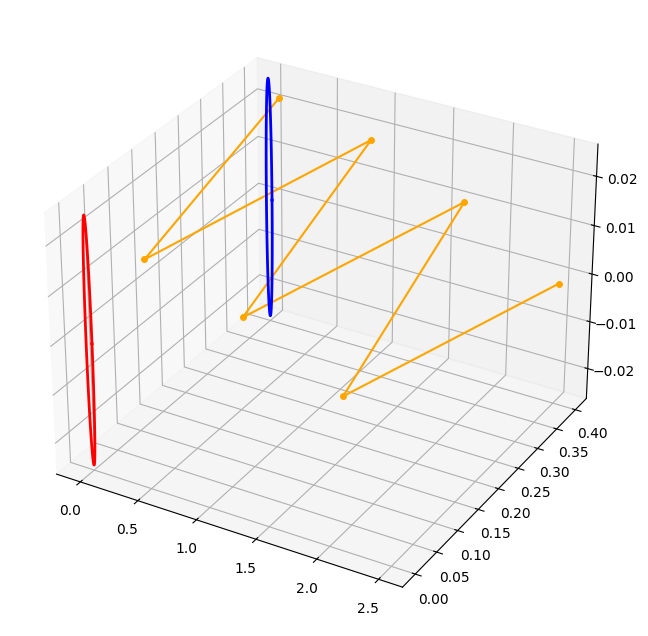

In [7]:
# Visualization: 3D ray path
if best_mem and best_mem.memory:
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Extract path
    path_points = []
    for state in best_mem.memory:
        path_points.append([state.position.x, state.position.y, state.position.z])
    
    if path_points:
        path_array = np.array(path_points)
        ax.plot(path_array[:, 0], path_array[:, 1], path_array[:, 2], 
                'o-', color='orange', label='Ray path', markersize=4)
    
    # Draw mirrors as circles
    mirror_radius = finder.mirror_radius_m
    
    # M1 at origin (xy-plane)
    theta_circle = np.linspace(0, 2*np.pi, 100)
    x_m1 = mirror_radius * np.cos(theta_circle)
    y_m1 = np.zeros_like(theta_circle)
    z_m1 = mirror_radius * np.sin(theta_circle)
    ax.plot(x_m1, y_m1, z_m1, 'r-', linewidth=2, label='M1')
    
    # M2 at (0, 0.6, 0)
    x_m2 = mirror_radius * np.cos(theta_circle)
    y_m2 = finder.pos_m2_base.y + np.zeros_like(theta_circle)
    z_m2 = mirror_radius * np.sin(theta_circle)
    ax.plot(x_m2, y_m2, z_m2, 'b-', linewidth=2, label='M2')
    
    # Draw detector plane
    det_x = np.linspace(-finder.detector_size_m/2, finder.detector_size_m/2, 10)
    det_z = np.linspace(-finder.detector_size_m/2, finder.detector_size_m/2, 10)
    det_X, det_Z = np.meshgrid(det_x, det_z)
    det_Y = finder.detector_distance_m * np.ones_like(det_X)
    ax.plot_surface(det_X, det_Y, det_Z, alpha=0.2, color='green', label='Detector')
    
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title(f'2-Mirror Multipass: {len(best_mem.memory)} passes')
    ax.legend()
    ax.set_box_aspect([1, 2, 1])
    plt.tight_layout()
    plt.savefig('2mirror_3d_path.png', dpi=150)
    plt.show()
    print("Visualization saved as '2mirror_3d_path.png'")

In [ ]:
# DEBUG: Test one configuration
debug_finder = TwoMirrorFindingGeometry(target_passes=10, iterations=100, mirror_sep_cm=40.0)
test_config = {"theta_x2": 0.0, "theta_y2": 0.0, "vertical_tilt": 0.0}

cell, entry_pt, laser_dir, m1, m2 = debug_finder._setup_cell(test_config)

print(f"M1 origin: {m1.origin}")
print(f"M1 normal: {m1.normal}")
print(f"M2 origin: {m2.origin}")
print(f"M2 normal: {m2.normal}")
print(f"Entry point (laser start): {entry_pt}")
print(f"Laser direction: {laser_dir}")

# Trace one ray
track_mem = debug_finder._trace_ray_until_exit(cell, entry_pt, laser_dir, max_reflections=50)
print(f"\nNumber of reflections: {len(track_mem.memory)}")

if track_mem.memory:
    for i, state in enumerate(track_mem.memory):
        print(f"  {i}: {state.mirror_name} at {state.position}, dir={state.direction}")
    
    # Check final spot error
    spot_error = debug_finder._compute_final_spot_error(track_mem, m2)
    print(f"\nFinal spot error: {spot_error}")
    print(f"Last reflection: {track_mem.memory[-1].mirror_name} at {track_mem.memory[-1].position}")
    print(f"Exit direction: {track_mem.memory[-1].direction}")
else:
    print("No reflections found!")

M1 origin: Vector(0.0, 0.0, 0.0)
M1 normal: Vector(0.0, 1.0, 0.0)
M2 origin: Vector(0.0, 0.4, 0.0)
M2 normal: Vector(0.0, -1.0, 0.0)
Entry point (laser start): Vector(-0.1, 0.2, 0.022)
Laser direction: Vector(0.7071067811865476, 0.7071067811865476, 0.0)

Number of reflections: 7
  0: M2 at Vector(0.1, 0.4, 0.022), dir=Vector(0.7071067811865476, -0.7071067811865476, 0.0)
  1: M1 at Vector(0.5, 0.0, 0.022), dir=Vector(0.7071067811865476, 0.7071067811865476, 0.0)
  2: M2 at Vector(0.9, 0.4, 0.022), dir=Vector(0.7071067811865476, -0.7071067811865476, 0.0)
  3: M1 at Vector(1.3, 0.0, 0.022), dir=Vector(0.7071067811865476, 0.7071067811865476, 0.0)
  4: M2 at Vector(1.7000000000000002, 0.4, 0.022), dir=Vector(0.7071067811865476, -0.7071067811865476, 0.0)
  5: M1 at Vector(2.1, 0.0, 0.022), dir=Vector(0.7071067811865476, 0.7071067811865476, 0.0)
  6: M2 at Vector(2.5, 0.4, 0.022), dir=Vector(0.7071067811865476, -0.7071067811865476, 0.0)

Final spot error: 0.1023914058893616
Last reflection: M2